# 1. Import Libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import torch.nn.functional as F

# 2. Import image dataset

In [4]:
data_dir = "/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT"  

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# 3. Transform image into tensor format

In [6]:
baseline_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# 4. Load Datasets

In [7]:
train_dataset = datasets.ImageFolder(train_dir, transform=baseline_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=baseline_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=baseline_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("Classes:", class_names)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


# 5. Visualisation

## 5.1. Display image of all 10 clasees

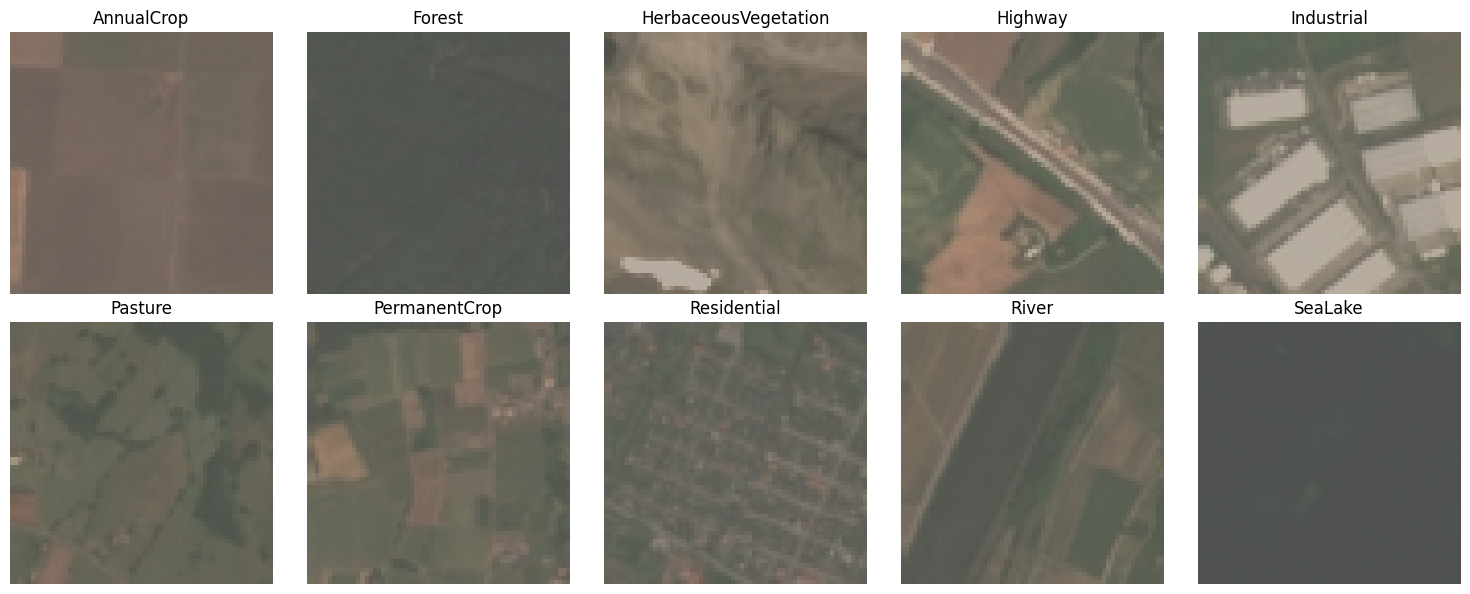

In [8]:
def show_one_per_class(dataset):
    num_classes = len(dataset.classes)
    cols = 5
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()

    class_seen = {}
    i = 0

    # ImageNet normalization values (used in most pretrained models like ResNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for img, label in dataset:
        if label not in class_seen:
            class_seen[label] = True

            # Convert CHW → HWC
            img_display = img.permute(1, 2, 0).cpu().numpy()

            # 🔥 Denormalize image
            img_display = (img_display * std) + mean

            # Clip values to valid range
            img_display = np.clip(img_display, 0, 1)

            axes[i].imshow(img_display)
            axes[i].set_title(dataset.classes[label])
            axes[i].axis("off")

            i += 1

        if len(class_seen) == num_classes:
            break

    # Hide unused subplots
    for j in range(i, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# Call function
show_one_per_class(train_dataset)

## 5.2. Visualise class distribution 

In [ ]:
# Get labels
labels = [label for _, label in train_dataset]

# Count occurrences
class_counts = Counter(labels)

# Convert to readable format
counts = [class_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)

plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.show()

# 6. Device Setup

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


---
# 7. Baseline Model

## 7.1. Baseline Model Architecture

In [8]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()

        # Convolutional feature extractor
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),              # Activation function (introduces non-linearity)
            nn.MaxPool2d(2),        # Downsamples image by factor of 2 (reduces H and W)
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)         # Again reduces spatial size by factor of 2 (kernel, stride)
        )

        # Fully connected classifier
        self.fc = nn.Sequential(
            nn.Flatten(),  # Converts feature maps into 1D vector
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),

            # Output layer
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Pass input through convolutional layers
        x = self.conv(x)

        # Flatten and pass through fully connected layers
        x = self.fc(x)

        # Output logits (no softmax here; loss function will handle it)
        return x

In [9]:
# First convolution layer:
# Input: 3 channels (RGB image)
# Output: 16 feature maps
# Kernel size: 3x3, padding keeps spatial size same

# Second convolution layer:
# Input: 16 channels → Output: 32 feature maps

# Fully connected layer:
# Input size = 32 feature maps * 16 * 16 spatial size
# (depends on input image size 64x64 → after 2 poolings → 16x16)

# Output layer:
# Produces probability logits for each class

## 7.2. Initialise Baseline Model

In [10]:
model = BaselineCNN(num_classes).to(device) 

## 7.3. Loss and Optimiser for Baseline Model

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 7.3. Train Baseline Model

In [12]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 30
best_val_acc = 0

print("Training Baseline Model...")

for epoch in range(epochs):

    # ---- TRAINING ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    # ---- SAVE BEST MODEL ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_baseline_model.pth")
        print("Saved Best Baseline Model")

    # ---- PRINT ----
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training Baseline Model...
Saved Best Baseline Model
Epoch 1/30 | Train Loss: 1.0682, Train Acc: 0.6118 | Val Loss: 0.7600, Val Acc: 0.7298
Saved Best Baseline Model
Epoch 2/30 | Train Loss: 0.6677, Train Acc: 0.7597 | Val Loss: 0.6105, Val Acc: 0.7929
Saved Best Baseline Model
Epoch 3/30 | Train Loss: 0.5399, Train Acc: 0.8041 | Val Loss: 0.5843, Val Acc: 0.7970
Epoch 4/30 | Train Loss: 0.4537, Train Acc: 0.8388 | Val Loss: 0.5927, Val Acc: 0.7891
Saved Best Baseline Model
Epoch 5/30 | Train Loss: 0.3776, Train Acc: 0.8614 | Val Loss: 0.4913, Val Acc: 0.8435
Epoch 6/30 | Train Loss: 0.3041, Train Acc: 0.8938 | Val Loss: 0.4926, Val Acc: 0.8337
Saved Best Baseline Model
Epoch 7/30 | Train Loss: 0.2495, Train Acc: 0.9127 | Val Loss: 0.4699, Val Acc: 0.8514
Epoch 8/30 | Train Loss: 0.2131, Train Acc: 0.9264 | Val Loss: 0.5512, Val Acc: 0.8278
Epoch 9/30 | Train Loss: 0.1645, Train Acc: 0.9429 | Val Loss: 0.5897, Val Acc: 0.8302
Epoch 10/30 | Train Loss: 0.1541, Train Acc: 0.9469 | Val Lo

## 7.4. Evaluate Baseline Model

Baseline Model Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       376
           1       0.92      0.93      0.92       376
           2       0.78      0.77      0.77       376
           3       0.63      0.73      0.68       375
           4       0.90      0.93      0.91       375
           5       0.80      0.86      0.83       300
           6       0.68      0.73      0.71       375
           7       0.94      0.89      0.91       376
           8       0.80      0.69      0.74       375
           9       0.96      0.95      0.96       376

    accuracy                           0.83      3680
   macro avg       0.83      0.83      0.83      3680
weighted avg       0.83      0.83      0.83      3680



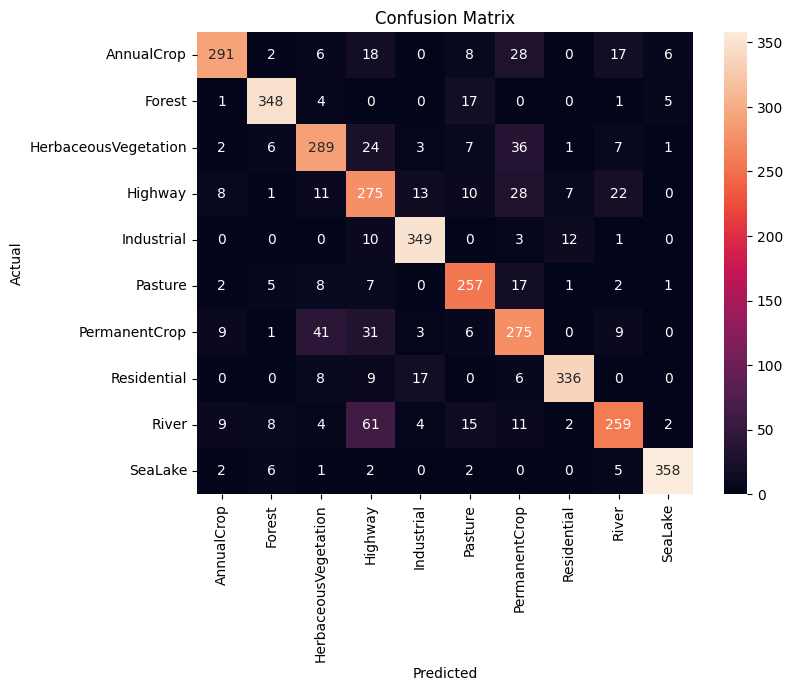

In [13]:
def evaluate(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

print("Baseline Model Evaluation")
evaluate(model, test_loader, class_names)

## 7.5. Plot Loss Curve

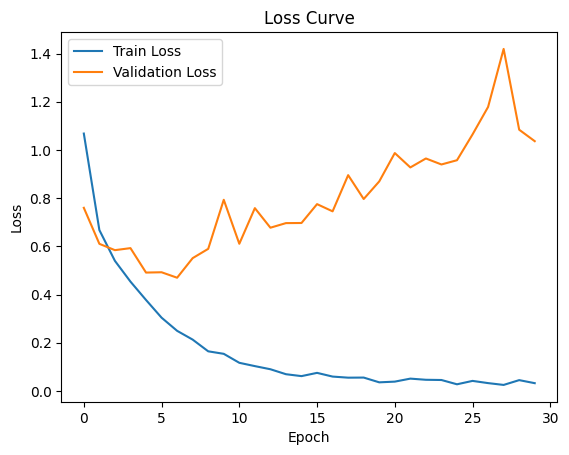

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 7.6. Plot Accuracy Curve

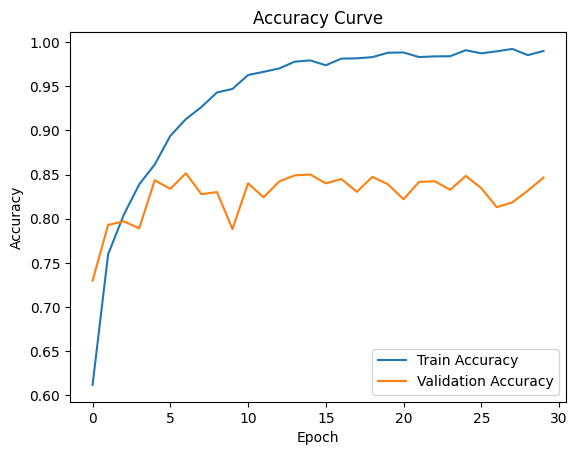

In [15]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## 7.7. Load model

In [16]:
model.load_state_dict(torch.load("best_baseline_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Baseline Model loaded successfully!")

Baseline Model loaded successfully!


## 7.8. Predict Baseline Model

In [17]:
class_names = train_dataset.classes

def predict_image_with_confidence(image_path):
    image = Image.open(image_path).convert("RGB")
    # reuse training transform
    image = baseline_transform(image).unsqueeze(0).to(device)
    assert image.shape[0] == 1  # batch size check

    with torch.no_grad():
        outputs = model(image)
    
        predicted = torch.argmax(outputs, dim=1)
        confidence = torch.softmax(outputs, dim=1)[0, predicted.item()]

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score

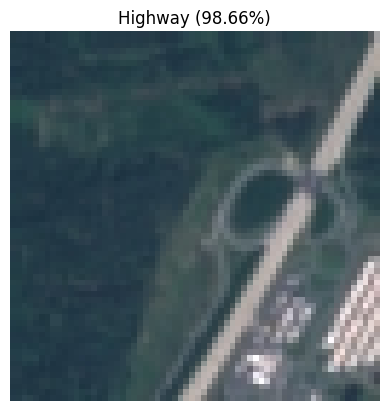

In [18]:
def show_prediction(image_path):
    predicted_class, confidence = predict_image_with_confidence(image_path)

    image = Image.open(image_path)

    plt.imshow(image)
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT/test/Highway/Highway_100.jpg")

---
# 8. Improved CNN Model

## 8.1. Transform and Load Model

In [19]:
aug_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(train_dir, transform=aug_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

## 8.2. Initialise ImprovedCNN Model

In [20]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()

        # Feature extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # NEW Block 3 (added depth)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),

            # 64 channels, size becomes 8×8 after 3 pools
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),

            nn.Dropout(0.5),   # Prevent overfitting

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ImprovedCNN(num_classes).to(device)

## 8.3. Loss and Optimiser for Improved CNN Model

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # lower LR for stability

## 8.4. Train Improved CNN Model

In [22]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 30
best_acc = 0
patience = 5
counter = 0

print("Training Improved CNN Model...")

for epoch in range(epochs):

    # ---------------- TRAINING ----------------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    # ---------------- LOG ----------------
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


    # ---------------- SAVE BEST MODEL ----------------
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_improved_model.pth")
        print("Best Improved CNN Model saved!")

    else:
        counter += 1

    # ---------------- EARLY STOPPING ----------------
    if counter >= patience:
        print("Early stopping triggered.")
        break

Training Improved CNN Model...
Epoch 1/30 | Train Loss: 1.1406, Train Acc: 0.5923 | Val Loss: 0.7340, Val Acc: 0.7521
Best Improved CNN Model saved!
Epoch 2/30 | Train Loss: 0.8183, Train Acc: 0.7169 | Val Loss: 0.6486, Val Acc: 0.7676
Best Improved CNN Model saved!
Epoch 3/30 | Train Loss: 0.7114, Train Acc: 0.7556 | Val Loss: 0.5375, Val Acc: 0.8190
Best Improved CNN Model saved!
Epoch 4/30 | Train Loss: 0.6501, Train Acc: 0.7762 | Val Loss: 0.4966, Val Acc: 0.8280
Best Improved CNN Model saved!
Epoch 5/30 | Train Loss: 0.6073, Train Acc: 0.7908 | Val Loss: 0.4606, Val Acc: 0.8430
Best Improved CNN Model saved!
Epoch 6/30 | Train Loss: 0.5476, Train Acc: 0.8139 | Val Loss: 0.6102, Val Acc: 0.7886
Epoch 7/30 | Train Loss: 0.5178, Train Acc: 0.8217 | Val Loss: 0.3833, Val Acc: 0.8642
Best Improved CNN Model saved!
Epoch 8/30 | Train Loss: 0.4862, Train Acc: 0.8340 | Val Loss: 0.5178, Val Acc: 0.8237
Epoch 9/30 | Train Loss: 0.4471, Train Acc: 0.8467 | Val Loss: 0.4108, Val Acc: 0.8620


## 8.5. Evaluate Improved CNN Model

Improved CNN Model Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       376
           1       0.91      0.98      0.94       376
           2       0.73      0.95      0.82       376
           3       0.90      0.83      0.87       375
           4       0.92      0.97      0.94       375
           5       0.85      0.88      0.87       300
           6       0.82      0.76      0.79       375
           7       0.96      0.95      0.96       376
           8       0.96      0.77      0.85       375
           9       0.98      0.95      0.96       376

    accuracy                           0.89      3680
   macro avg       0.89      0.89      0.89      3680
weighted avg       0.90      0.89      0.89      3680



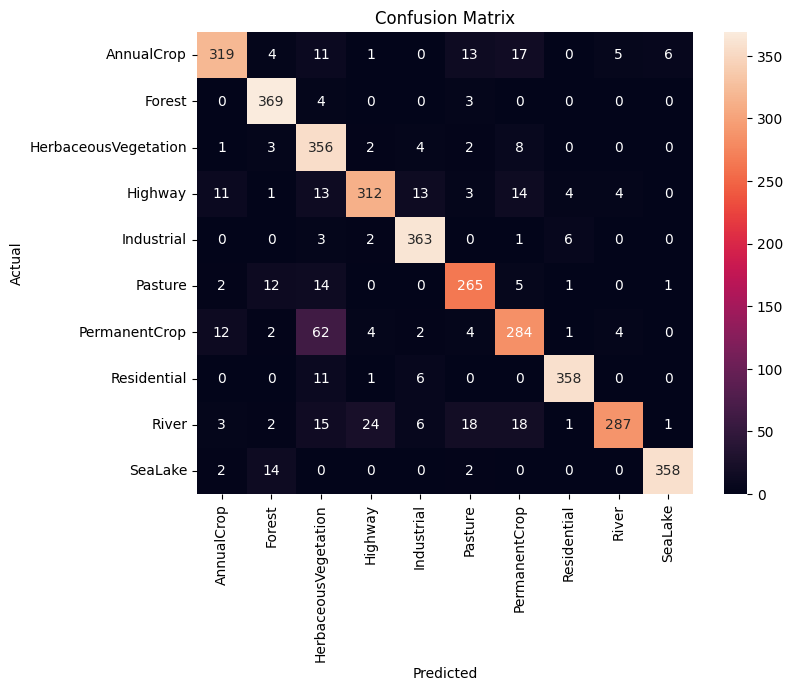

In [23]:
print("Improved CNN Model Evaluation")
evaluate(model, test_loader, class_names)

## 8.6. Plot Loss Curve

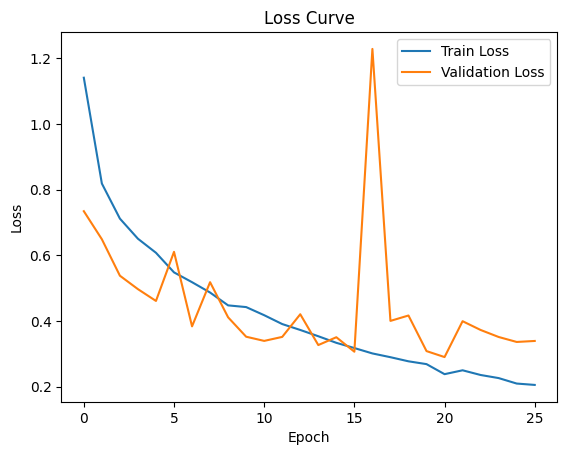

In [24]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 8.7. Plot Accuracy Curve

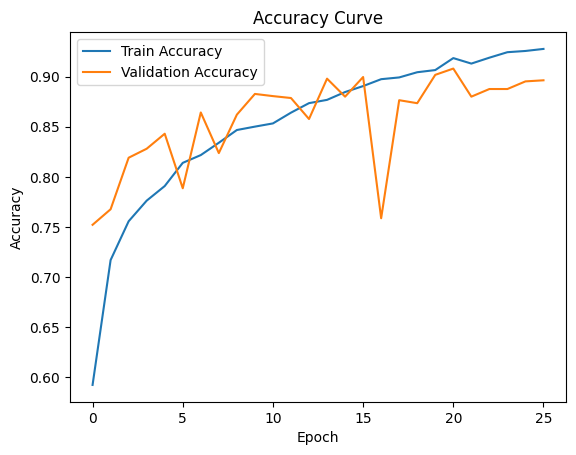

In [25]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## 8.8. Load saved model

In [26]:
model.load_state_dict(torch.load("best_improved_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Improved Model loaded successfully!")

class_names = train_dataset.classes
print(class_names)

Improved Model loaded successfully!
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 8.9. Predict Improved CNN Model

In [27]:
def predict_image_with_confidence(image_path):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image = baseline_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        # Predicted class
        predicted = torch.argmax(outputs, dim=1)

        # Confidence (softmax probability)
        probs = F.softmax(outputs, dim=1)
        confidence = probs[0, predicted.item()]

    return class_names[predicted.item()], confidence.item() * 100

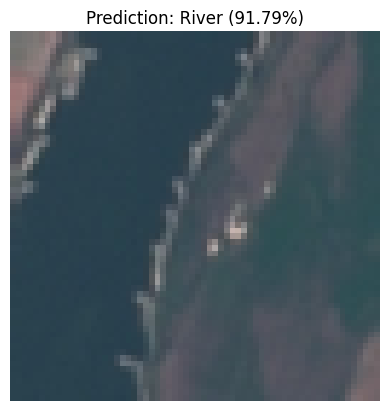

In [28]:
def show_prediction(image_path):
    predicted_class, confidence = predict_image_with_confidence(image_path)

    # Load image only for display
    image = Image.open(image_path)

    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT/test/River/River_11.jpg")

---
# 9. Pre-Trained Model (ResNet18)

## 9.1. Transform images to Tensor format

In [29]:
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_resnet = datasets.ImageFolder(train_dir, transform=resnet_transform)
val_resnet = datasets.ImageFolder(val_dir, transform=resnet_transform)
test_resnet = datasets.ImageFolder(test_dir, transform=resnet_transform)

train_loader = DataLoader(train_resnet, batch_size=32, shuffle=True)
val_loader = DataLoader(val_resnet, batch_size=32)
test_loader = DataLoader(test_resnet, batch_size=32)

## 9.2. Load pretrained model

In [30]:
model = models.resnet18(pretrained=True)

# Freeze early layers
for name, param in model.named_parameters():
   if "layer4" not in name and "fc" not in name:
      param.requires_grad = False


# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


## 9.3. Loss & Optimizer

In [31]:
criterion = nn.CrossEntropyLoss()
# Only train final layer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

## 9.4. Training Setup

In [32]:
epochs = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0

# -------- EARLY STOPPING SETTINGS --------
patience = 5
counter = 0

print("Training Pretrained ResNet18 Model...")

for epoch in range(epochs):

    # ---------------- TRAINING ----------------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total


    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total


    # ---------------- STORE METRICS ----------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    # ---------------- PRINT ----------------
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


    # ---------------- SAVE BEST MODEL ----------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "resnet18_best.pth")
        print("Best pretrained model saved!")

    else:
        counter += 1


    # ---------------- EARLY STOPPING ----------------
    if counter >= patience:
        print("Early stopping triggered.")
        break

Training Pretrained ResNet18 Model...
Epoch 1/20 | Train Loss: 134.4227, Acc: 0.9187 | Val Loss: 10.2341, Acc: 0.9703
Best pretrained model saved!
Epoch 2/20 | Train Loss: 59.4139, Acc: 0.9629 | Val Loss: 12.1546, Acc: 0.9663
Epoch 3/20 | Train Loss: 40.9531, Acc: 0.9732 | Val Loss: 13.5162, Acc: 0.9652
Epoch 4/20 | Train Loss: 36.0344, Acc: 0.9787 | Val Loss: 12.7738, Acc: 0.9698
Epoch 5/20 | Train Loss: 24.8883, Acc: 0.9848 | Val Loss: 10.0198, Acc: 0.9755
Best pretrained model saved!
Epoch 6/20 | Train Loss: 19.6366, Acc: 0.9878 | Val Loss: 10.0151, Acc: 0.9752
Epoch 7/20 | Train Loss: 17.5159, Acc: 0.9890 | Val Loss: 10.9750, Acc: 0.9731
Epoch 8/20 | Train Loss: 18.4790, Acc: 0.9886 | Val Loss: 11.1009, Acc: 0.9722
Epoch 9/20 | Train Loss: 14.5036, Acc: 0.9909 | Val Loss: 12.2907, Acc: 0.9739
Epoch 10/20 | Train Loss: 10.6859, Acc: 0.9932 | Val Loss: 9.1120, Acc: 0.9793
Best pretrained model saved!
Epoch 11/20 | Train Loss: 11.3985, Acc: 0.9933 | Val Loss: 19.8476, Acc: 0.9614
Epoc

## 9.5. Evaluate ResNet18 Model

Pretrained (ResNet) Model Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       376
           1       0.98      0.99      0.99       376
           2       0.94      0.97      0.95       376
           3       1.00      0.95      0.97       375
           4       0.98      0.99      0.99       375
           5       0.95      0.96      0.95       300
           6       0.97      0.93      0.95       375
           7       0.99      0.99      0.99       376
           8       0.97      0.98      0.97       375
           9       0.99      0.99      0.99       376

    accuracy                           0.97      3680
   macro avg       0.97      0.97      0.97      3680
weighted avg       0.97      0.97      0.97      3680



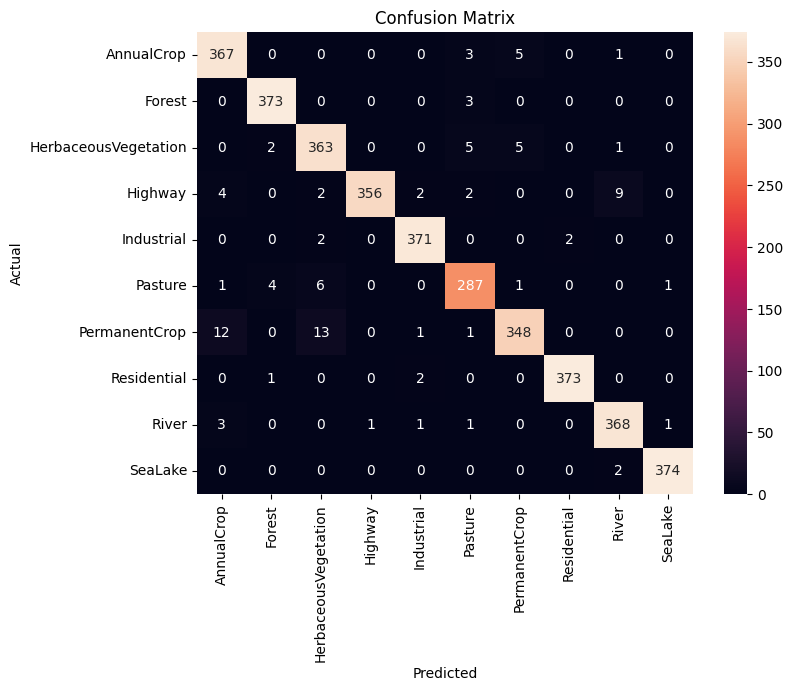

In [33]:
print("Pretrained (ResNet) Model Evaluation")
evaluate(model, test_loader, class_names)

## 9.6. Plot ResNet18 Model Loss Curve

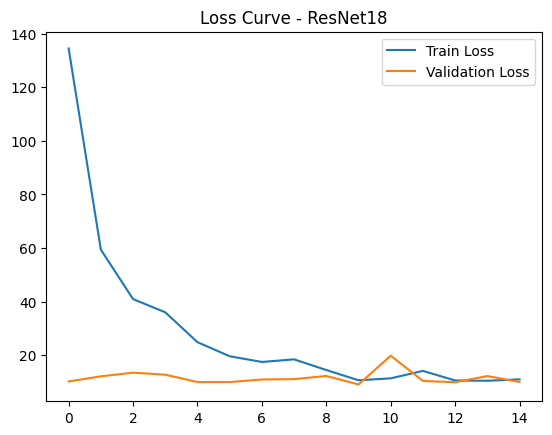

In [34]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve - ResNet18")
plt.show()

## 9.7. Plot ResNet18 Model Accuracy Curve

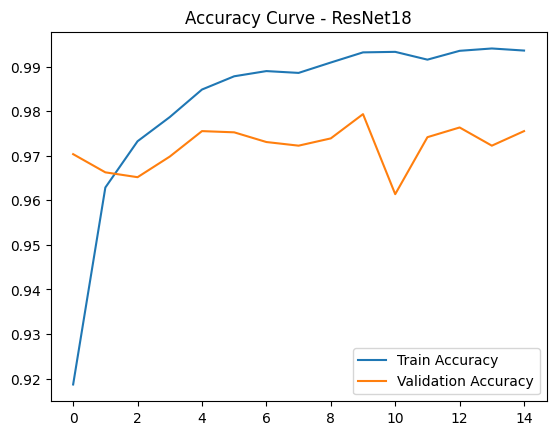

In [35]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve - ResNet18")
plt.show()

## 9.8. Load Best Model

In [36]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("resnet18_best.pth", map_location=device))
model = model.to(device)
model.eval()

print("Pretrained (ResNet18) Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Pretrained (ResNet18) Model loaded successfully!


## 9.9. Predict ResNet18 Model

In [37]:
# Replace final layer (MUST match training)
num_classes = len(class_names)

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    original = image.copy()

    image = resnet_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

    return class_names[predicted.item()], confidence.item()*100, original

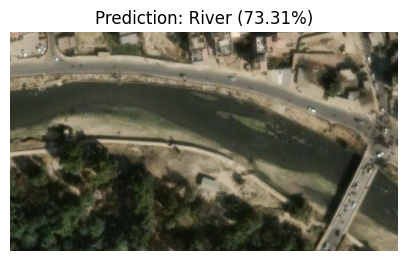

Predicted Class: River
Confidence: 73.31%


In [38]:
def show_prediction(image_path):
    label, confidence, image = predict_image(image_path)

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.show()

    print(f"Predicted Class: {label}")
    print(f"Confidence: {confidence:.2f}%")


show_prediction("/kaggle/input/datasets/natashashrestha77/images/River2.png")